# Removing Background Version-1

In [2]:
# ! conda create -n inpaint310 python=3.10 -y
# ! conda activate inpaint310

In [ ]:
pip install torch torchvision --extra-index-url https://download.pytorch.org/whl/cpu
# 如果你是 Apple 芯片且想用 MPS，直接 pip 安装 torch 即可（无需上面 index-url）
pip install craft-text-detector opencv-python scikit-image pillow numpy
# 轻量进阶：装 “lama-cleaner” 做 LaMa/ZITS 推理（会自动拉权重）
pip install lama-cleaner==0.39.0

In [8]:
! conda list opencv

# packages in environment at /opt/anaconda3/envs/cv_env:
#
# Name                    Version                   Build  Channel
opencv                    4.10.0           py39h3af0ddd_7  


In [ ]:
# ! pip install craft-text-detector

: 

In [ ]:
!python -m pip uninstall -y opencv-python scikit-image
!python -m pip install -U "numpy>=2.0" "opencv-python>=4.10.0.84" "scikit-image>=0.24" "pillow>=10.3"

!python -m pip install -U ipykernel
!python -m ipykernel install --user --name inpaint310 --display-name "inpaint310"

!export PIP_USER=0

In [4]:
import platform
print('Python:', platform.python_version())
try:
    import torch
    dev = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
    print('Torch:', torch.__version__, '| device:', dev)
except Exception as e:
    print('Torch 未安装或不可用：', e)

for name in ['cv2','numpy','PIL','skimage']:
    try:
        __import__(name if name!='PIL' else 'PIL.Image')
        print(f'{name} ✓')
    except Exception as e:
        print(f'{name} x -> {e}')

Python: 3.10.19
Torch: 2.9.0 | device: mps
cv2 ✓
numpy ✓
PIL ✓
skimage ✓


objc[59720]: Class CaptureDelegate is implemented in both /opt/anaconda3/envs/inpaint310/lib/python3.10/site-packages/cv2/cv2.cpython-310-darwin.so (0x119412398) and /opt/anaconda3/envs/inpaint310/lib/python3.10/site-packages/cv2/cv2.abi3.so (0x15e7aa5d8). One of the two will be used. Which one is undefined.
objc[59720]: Class CVWindow is implemented in both /opt/anaconda3/envs/inpaint310/lib/python3.10/site-packages/cv2/cv2.cpython-310-darwin.so (0x1194123e8) and /opt/anaconda3/envs/inpaint310/lib/python3.10/site-packages/cv2/cv2.abi3.so (0x15e7aa628). One of the two will be used. Which one is undefined.
objc[59720]: Class CVView is implemented in both /opt/anaconda3/envs/inpaint310/lib/python3.10/site-packages/cv2/cv2.cpython-310-darwin.so (0x119412410) and /opt/anaconda3/envs/inpaint310/lib/python3.10/site-packages/cv2/cv2.abi3.so (0x15e7aa650). One of the two will be used. Which one is undefined.
objc[59720]: Class CVSlider is implemented in both /opt/anaconda3/envs/inpaint310/lib/

In [13]:
from craft_text_detector import Craft
import cv2, numpy as np, os

def generate_text_mask(image_path: str, mask_path: str, dilate_px: int = 4, min_area: int = 80, use_cuda: bool = False):
    """
    image_path: 输入图片
    mask_path: 输出的二值mask路径（PNG）
    dilate_px: 对检测到的区域膨胀的像素，2~6常见
    min_area: 小于该面积的多边形忽略
    use_cuda: 是否使用CUDA（一般macOS为False）
    """
    craft = Craft(output_dir='craft_out', crop_type='poly', cuda=use_cuda)
    pred = craft.detect_text(image_path)
    polys = pred.get('boxes', [])
    img = cv2.imread(image_path)
    assert img is not None, f'无法读取图像: {image_path}'
    H, W = img.shape[:2]
    mask = np.zeros((H, W), dtype=np.uint8)

    # 栅格化 + 面积过滤
    for poly in polys:
        poly = np.array(poly, dtype=np.int32)
        area = cv2.contourArea(poly)
        if area >= min_area:
            cv2.fillPoly(mask, [poly], 255)

    # 边缘膨胀，减少修复边界露馅
    if dilate_px > 0:
        k = 2 * dilate_px + 1
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        mask = cv2.dilate(mask, kernel)

    os.makedirs(os.path.dirname(mask_path) or '.', exist_ok=True)
    cv2.imwrite(mask_path, mask)
    craft.unload_craftnet_model(); craft.unload_refinenet_model()
    return mask

print('generate_text_mask 函数已定义。')

generate_text_mask 函数已定义。


In [2]:
# conda activate inpaint310

# 先卸载，避免残留
! python -m pip uninstall -y torchvision torch torchaudio

# 安装兼容组合（含 model_urls）
# CPU 通用（macOS/Intel/M1 都能跑；MPS 不需要就用CPU没问题）
! python -m pip install --index-url https://download.pytorch.org/whl/cpu \
  torch==1.11.0 torchvision==0.12.0

# 可选：再确认其他依赖保持一致
! python -m pip install "numpy==1.26.4" "opencv-python==4.9.0.80" "scikit-image==0.22.*" "pillow>=10.0"

# # 注册 Jupyter 内核（确保 Notebook 用的是这个环境）
# ! python -m pip install -U ipykernel
# ! python -m ipykernel install --user --name inpaint310 --display-name "inpaint310"

Found existing installation: torchvision 0.12.0
Uninstalling torchvision-0.12.0:
  Successfully uninstalled torchvision-0.12.0
Found existing installation: torch 1.11.0
Uninstalling torch-1.11.0:
  Successfully uninstalled torch-1.11.0
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-1.11.0-cp310-none-macosx_11_0_arm64.whl (43.1 MB)
  Using cached https://download.pytorch.org/whl/torchvision-0.12.0-cp310-cp310-macosx_11_0_arm64.whl (1.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] [torchvision]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
craft-text-detector 0.4.3 requires opencv-python<4.5.4.62,>=3.4.8.29, but you have opencv-python 4.9.0.80 which is incompatible.


In [8]:
# 注册 Jupyter 内核（确保 Notebook 用的是这个环境）
! python -m pip install -U ipykernel
! python -m ipykernel install --user --name inpaint310 --display-name "inpaint310"

Installed kernelspec inpaint310 in /Users/suleynan_suir/Library/Jupyter/kernels/inpaint310


In [3]:
import sys, numpy as np, torchvision, cv2
import torchvision.models.vgg as vgg
print(sys.executable)
print('torchvision:', torchvision.__version__)
print('has model_urls?', hasattr(vgg, 'model_urls'))
print('numpy:', np.__version__, 'cv2:', cv2.__version__)

/opt/anaconda3/envs/inpaint310/bin/python3.10
torchvision: 0.12.0
has model_urls? True
numpy: 1.26.4 cv2: 4.9.0


In [4]:
# 示例路径（请替换为你的实际路径）
# /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/01258.png
input_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/01258.png'           # <- 改成你的图片
# /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck
output_mask = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01258_mask.png'

# 生成mask（常用：dilate_px=4，min_area=80~200）
generate_text_mask(input_image, output_mask, dilate_px=4, min_area=120, use_cuda=False)

Craft text detector weight will be downloaded to /Users/suleynan_suir/.craft_text_detector/weights/craft_mlt_25k.pth


Downloading...
From: https://drive.google.com/uc?id=1bupFXqT-VU6Jjeul13XP7yx2Sg5IHr4J
To: /Users/suleynan_suir/.craft_text_detector/weights/craft_mlt_25k.pth
100%|██████████| 83.2M/83.2M [00:12<00:00, 6.51MB/s]


Craft text refiner weight will be downloaded to /Users/suleynan_suir/.craft_text_detector/weights/craft_refiner_CTW1500.pth


Downloading...
From: https://drive.google.com/uc?id=1xcE9qpJXp4ofINwXWVhhQIh9S8Z7cuGj
To: /Users/suleynan_suir/.craft_text_detector/weights/craft_refiner_CTW1500.pth
100%|██████████| 1.85M/1.85M [00:01<00:00, 1.13MB/s]


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [ ]:
! pip install lama-cleaner

In [ ]:
! pip install -U iopaint

In [23]:
! pip install -U iopaint opencv-python pillow matplotlib

  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached pillow-12.0.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.8 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 6.7 MB/s  0:00:06m0:00:0100:01
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.9.0.80
    Uninstalling opencv-python-4.9.0.80:
      Successfully uninstalled opencv-python-4.9.0.80
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
craft-text-detector 0.4.3 requires opencv-python<4.5.4.62,>=3.4.8.29, but you have opencv-python 4.11.0.86 which is incompatible.
lama-cleaner 1.2.5 requires diffusers==0.16.1, but you have diffusers 0.27.2 which is incompatible.

In [ ]:
# input_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/01258.png'  
# output_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01258_mask.png'
# lama_output = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01258output_lama.png'

## Basic Model Remove txt

In [13]:
from craft_text_detector import Craft
import cv2, numpy as np, os

In [1]:
from craft_text_detector import Craft
import cv2, numpy as np, os

def generate_text_mask(image_path: str, mask_path: str, dilate_px: int = 4, min_area: int = 80, use_cuda: bool = False):
    """
    image_path: 输入图片
    mask_path: 输出的二值mask路径（PNG）
    dilate_px: 对检测到的区域膨胀的像素，2~6常见
    min_area: 小于该面积的多边形忽略
    use_cuda: 是否使用CUDA（一般macOS为False）
    """
    craft = Craft(output_dir='craft_out', crop_type='poly', cuda=use_cuda)
    pred = craft.detect_text(image_path)
    polys = pred.get('boxes', [])
    img = cv2.imread(image_path)
    assert img is not None, f'无法读取图像: {image_path}'
    H, W = img.shape[:2]
    mask = np.zeros((H, W), dtype=np.uint8)

    # 栅格化 + 面积过滤
    for poly in polys:
        poly = np.array(poly, dtype=np.int32)
        area = cv2.contourArea(poly)
        if area >= min_area:
            cv2.fillPoly(mask, [poly], 255)

    # 边缘膨胀，减少修复边界露馅
    if dilate_px > 0:
        k = 2 * dilate_px + 1
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        mask = cv2.dilate(mask, kernel)

    os.makedirs(os.path.dirname(mask_path) or '.', exist_ok=True)
    cv2.imwrite(mask_path, mask)
    craft.unload_craftnet_model(); craft.unload_refinenet_model()
    return mask

print('generate_text_mask 函数已定义。')

generate_text_mask 函数已定义。


- 生成掩码

In [3]:
# input_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png'           # <- 改成你的图片
input_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/97436.png'

# /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck
output_mask = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/97436_mask.png'

# 生成mask（常用：dilate_px=4，min_area=80~200）
generate_text_mask(input_image, output_mask, dilate_px=4, min_area=120, use_cuda=False)

ImportError: cannot import name '_cast_Long' from 'torch.onnx.symbolic_opset9' (/opt/anaconda3/envs/inpaint310/lib/python3.10/site-packages/torch/onnx/symbolic_opset9.py)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def inpaint_one_cv(
    image_path: str,
    mask_path: str,
    out_path: str,
    method: str = "telea",     # "telea" 或 "ns"（Navier-Stokes）
    radius: int = 3,           # 修复半径，文本细条建议 2~5
    dilate_px: int = 0,        # 掩码可选膨胀像素，边界更干净可设 1~3
    show: bool = True          # 是否出图（四联图）
) -> str:
    """
    一站式输入输出：读图 -> 掩码对齐/二值化 -> OpenCV inpaint -> 保存 -> 可视化
    完全不使用 Pillow/imageio，避免 PNG 插件报错。
    """

    # ---- 1) 基础检查 ----
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"原图不存在：{image_path}")
    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"掩码不存在：{mask_path}")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    # ---- 2) 读图（OpenCV）----
    # 用 IMREAD_UNCHANGED 兼容 RGBA / 浮点 / 16bit 等，再转 BGR3
    src = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if src is None:
        raise RuntimeError(f"无法解码图像：{image_path}")
    if src.ndim == 2:  # 灰度 -> BGR
        bgr = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)
    elif src.ndim == 3 and src.shape[2] == 4:  # BGRA -> BGR
        bgr = cv2.cvtColor(src, cv2.COLOR_BGRA2BGR)
    elif src.ndim == 3 and src.shape[2] == 3:
        bgr = src
    else:
        raise RuntimeError(f"不支持的图像形状：{src.shape}")
    # 仅用于展示：转 RGB
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # ---- 3) 读掩码并标准化 ----
    m = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise RuntimeError(f"无法解码掩码：{mask_path}")
    if m.ndim == 3:  # 彩色/带A通道 -> 灰度
        if m.shape[2] == 4:
            m = cv2.cvtColor(m, cv2.COLOR_BGRA2BGR)
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
    # 尺寸对齐
    if (m.shape[0], m.shape[1]) != (rgb.shape[0], rgb.shape[1]):
        m = cv2.resize(m, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    # 二值化：白=需要修复区域
    _, mask_bin = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)

    # 可选：膨胀掩码，扩大修复范围（处理贴边文字更干净）
    if dilate_px > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*dilate_px + 1, 2*dilate_px + 1))
        mask_bin = cv2.dilate(mask_bin, k, iterations=1)

    # ---- 4) Inpaint（OpenCV）----
    if mask_bin.sum() == 0:
        # 掩码全黑：直接复制
        print("[提示] 掩码全黑，没有需要修复的区域，直接复制原图到输出。")
        out_bgr = bgr.copy()
    else:
        algo = cv2.INPAINT_TELEA if method.lower() == "telea" else cv2.INPAINT_NS
        out_bgr = cv2.inpaint(bgr, (mask_bin > 0).astype(np.uint8), radius, algo)

    # 保存
    cv2.imwrite(out_path, out_bgr)

    # ---- 5) 可视化（四联图）----
    if show:
        overlay = rgb.copy()
        red = np.zeros_like(overlay); red[..., 0] = 255  # 红色
        alpha = (mask_bin > 0).astype(np.float32) * 0.45
        overlay = (overlay * (1 - alpha[..., None]) + red * (alpha[..., None])).astype(np.uint8)

        out_rgb = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(16, 9))
        panels = [
            (cv2.cvtColor(mask_bin, cv2.COLOR_GRAY2RGB), "Mask (w-target RoI)"),
            (overlay, "Raw + Msk"),
            (rgb, "Raw"),
            (out_rgb, f"Output: (OpenCV inpaint-{method}, r-{radius})"),
        ]
        for i, (im, title) in enumerate(panels, 1):
            ax = plt.subplot(1, 4, i)
            ax.imshow(im)
            ax.set_title(title, fontsize=12, weight="bold")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return out_path


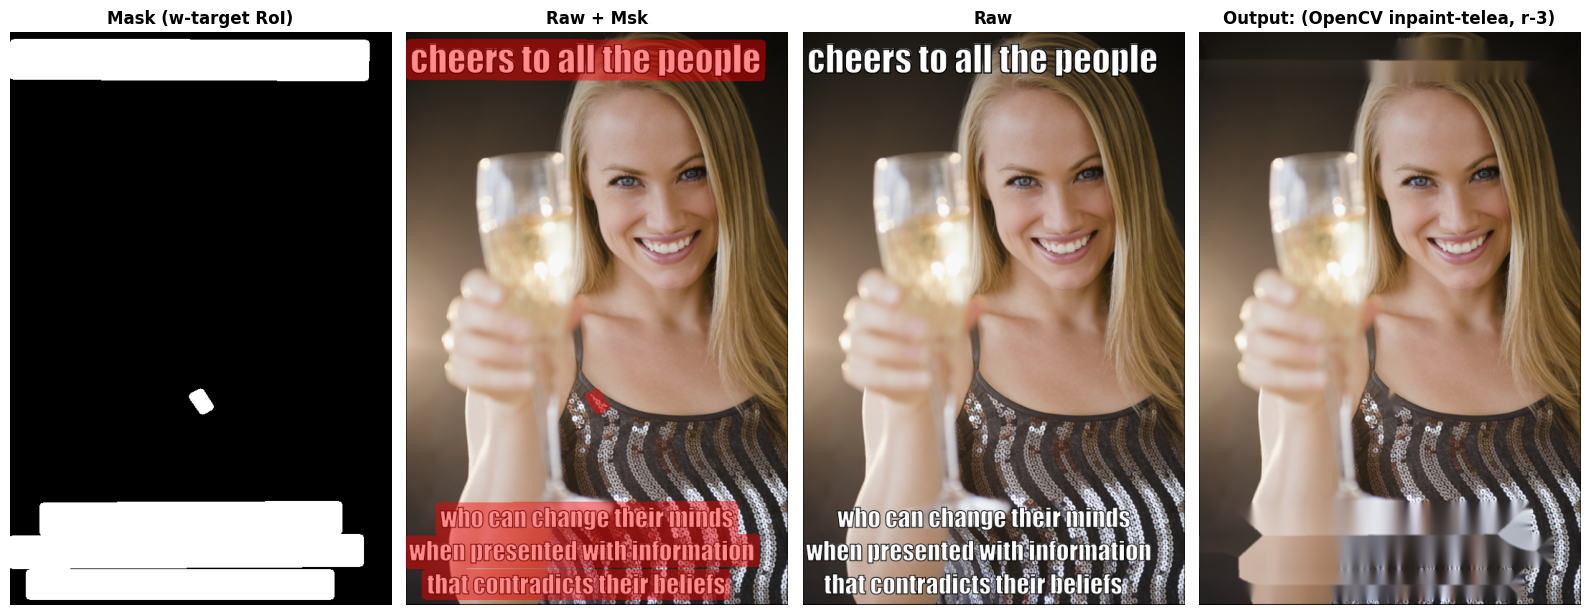

'/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv.png'

In [19]:
input_image = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png"
mask_path   = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457_mask.png"
lama_output = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv.png"

inpaint_one_cv(
    image_path=input_image,
    mask_path=mask_path,
    out_path=lama_output,
    method="telea",    # 或 "ns"
    radius=3,          # 可调：2~5
    dilate_px=1,       # 掩码边缘稍微膨胀 1 像素，清理更干净
    show=True
)


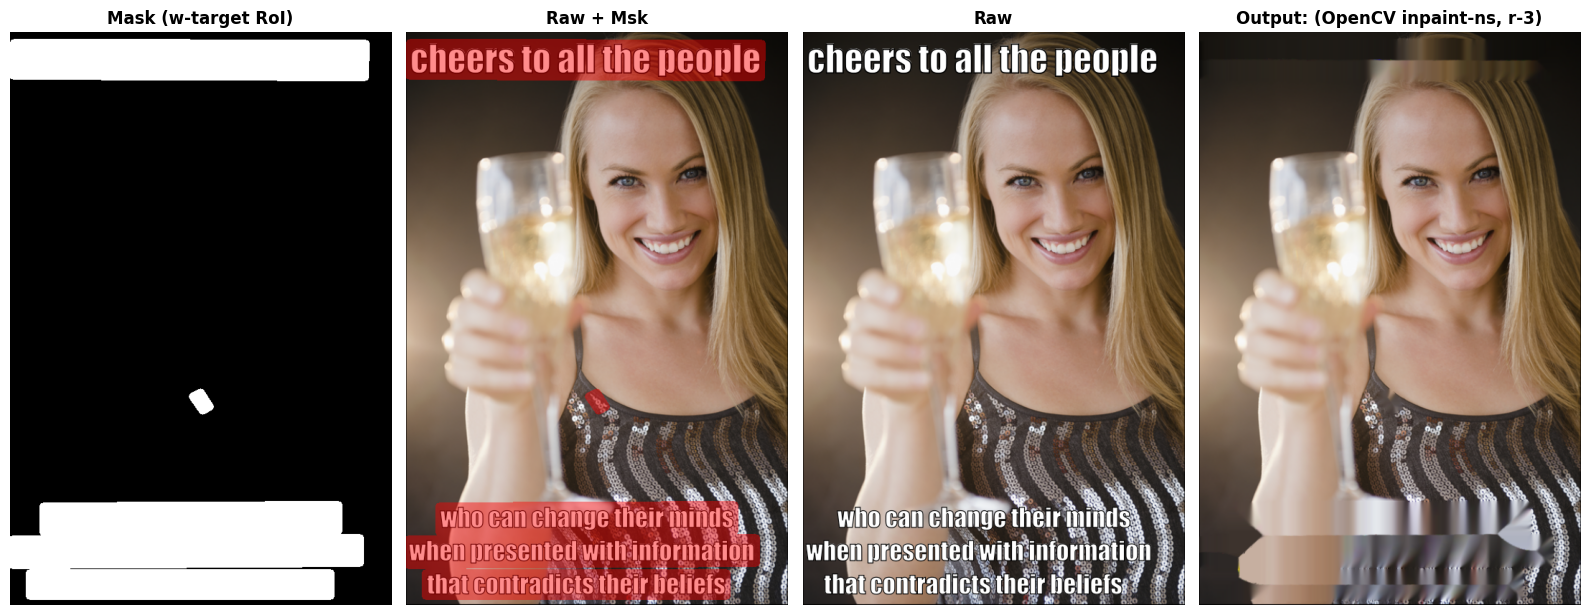

'/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv_ns.png'

In [20]:
input_image = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png"
mask_path   = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457_mask.png"
lama_output = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv_ns.png"

inpaint_one_cv(
    image_path=input_image,
    mask_path=mask_path,
    out_path=lama_output,
    method="ns",    # 或 "ns"
    radius=3,          # 可调：2~5
    dilate_px=1,       # 掩码边缘稍微膨胀 1 像素，清理更干净
    show=True
)

---

还原水平较差

## Better Version

In [5]:
import cv2
import numpy as np

def preprocess_image(image_path, mask_path, dilate_px=3):
    """
    Reads and normalizes the input image and mask, with optional dilation of the mask.
    """
    # Read the input image
    src = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if src is None:
        raise RuntimeError(f"Unable to decode image: {image_path}")

    # Handle different image types (e.g., grayscale, BGR, BGRA)
    if src.ndim == 2:
        bgr = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)
    elif src.ndim == 3 and src.shape[2] == 4:
        bgr = cv2.cvtColor(src, cv2.COLOR_BGRA2BGR)
    elif src.ndim == 3 and src.shape[2] == 3:
        bgr = src
    else:
        raise RuntimeError(f"Unsupported image shape: {src.shape}")
    
    # Convert to RGB for better visualization
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    H, W = rgb.shape[:2]

    # Read and normalize the mask
    m = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise RuntimeError(f"Unable to decode mask: {mask_path}")
    if m.ndim == 3:
        if m.shape[2] == 4:
            m = cv2.cvtColor(m, cv2.COLOR_BGRA2BGR)
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)

    if (m.shape[0], m.shape[1]) != (H, W):
        m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)

    _, mask_bin = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)

    # Apply slight dilation to the mask to avoid boundary artifacts
    if dilate_px > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * dilate_px + 1, 2 * dilate_px + 1))
        mask_bin = cv2.dilate(mask_bin, k, iterations=1)

    return rgb, mask_bin


In [6]:
import subprocess
import shlex
import os

def _call_lama_cleaner(model: str, image_path: str, mask_path: str, out_path: str, device: str = "cpu"):
    """
    Run the lama-cleaner command with proper logging to capture errors.
    """
    print(f'\nout_path: {out_path}')
    
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    
    # Updated command to reflect the correct mask argument
    cmd = f"lama-cleaner --model {model} --device {device} " \
          f"--input {shlex.quote(image_path)} --mask {shlex.quote(mask_path)} --output {shlex.quote(out_path)}"
    
    print("[lama-cleaner] Executing command:", cmd)
    
    # Run the command and capture output and errors
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    # Print the output and error logs
    print("[lama-cleaner] STDOUT:", result.stdout)
    print("[lama-cleaner] STDERR:", result.stderr)
    
    print(f'os.path.exists(out_path): {os.path.exists(out_path)}')
    print(f'result.returncode != 0: {result.returncode != 0}')
    print(f'out_path: {out_path}')
    
    if result.returncode != 0 or not os.path.exists(out_path):
        raise RuntimeError(f"lama-cleaner failed with return code {result.returncode}. See output and error messages above.")


In [7]:
def run_lama(image_path, mask_path, out_path, device="cpu"):
    """
    Run LaMa inpainting model on the image to restore the structure.
    """
    _call_lama_cleaner("lama", image_path, mask_path, out_path, device=device)

In [8]:
import os
# /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png
input_image = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png"
# /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457_mask.png
mask_path = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457_mask.png"

print(os.path.exists(input_image))  # Should return True
print(os.path.exists(mask_path))   # Should return True

True
True


In [9]:
def run_zits(image_path, mask_path, out_path, device="cpu"):
    """
    Run ZITS inpainting model to add finer details after LaMa inpainting.
    """
    _call_lama_cleaner("zits", image_path, mask_path, out_path, device=device)

In [10]:
def blend_images(base_path, detail_path, mask_path, final_output_path):
    """
    Apply Poisson blending to combine the structure (base) and texture (detail) seamlessly.
    """
    _poisson_blend(detail_path, base_path, mask_path, final_output_path)

In [11]:
def inpaint_high_quality(image_path, mask_path, out_path, device="cpu", dilate_px=3, show=False):
    """
    Full pipeline for high-quality inpainting with LaMa, ZITS, and Poisson blending.
    """
    # Preprocess image and mask
    rgb, mask_bin = preprocess_image(image_path, mask_path, dilate_px=dilate_px)

    # Temporary output paths
    print(f'out_path: {out_path}')
    base_out = out_path.replace(".png", "_lama.png").replace(".jpg", "_lama.png")
    print(f'base_out: {base_out}')
    detail_out = out_path.replace(".png", "_zits.png").replace(".jpg", "_zits.png")
    blend_out = out_path  # Final blended result

    # Run LaMa inpainting
    run_lama(image_path, mask_path, base_out, device=device)

    # Run ZITS inpainting
    run_zits(image_path, mask_path, detail_out, device=device)

    # Perform Poisson blending to merge LaMa and ZITS results
    blend_images(base_out, detail_out, mask_path, blend_out)

    # Show the result if required
    if show:
        out_bgr = cv2.imread(blend_out, cv2.IMREAD_COLOR)
        out_rgb = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(16, 9))
        plt.subplot(1, 2, 1)
        plt.imshow(rgb)
        plt.title("Original Image")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(out_rgb)
        plt.title(f"Inpainted Image")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return blend_out

In [ ]:
# input_image = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png"
# mask_path   = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457_mask.png"
# lama_output = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv_telea.png"

In [12]:
input_image = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png"
mask_path = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457_mask.png"
lama_output = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv.png"

# Run the high-quality inpainting pipeline
inpaint_high_quality(input_image, mask_path, lama_output, device="cpu", dilate_px=3, show=True)


out_path: /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv.png
base_out: /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv_lama.png

out_path: /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv_lama.png
[lama-cleaner] Executing command: lama-cleaner --model lama --device cpu --input /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/98457.png --mask /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457_mask.png --output /Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/98457output_opencv_lama.png
[lama-cleaner] STDOUT: 
[lama-cleaner] STDERR: usage: lama-cleaner [-h] [--host 

RuntimeError: lama-cleaner failed with return code 2. See output and error messages above.